# RQ4 MASTER EXPERIMENT: SCALING LAWS OF COGNITIVE FATIGUE

In [1]:
import subprocess
import sys
import gc
import os
import shutil
import time

In [2]:
def install(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", package])

print("[SETUP] Installing dependencies...")
try:
    import bitsandbytes
except ImportError:
    install("bitsandbytes")
    install("accelerate")
    install("transformers")
    install("datasets")
    install("scipy")
    install("seaborn")
    install("matplotlib")


[SETUP] Installing dependencies...


In [3]:
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from datasets import load_dataset
from scipy.stats import linregress

In [4]:
# Global Reproducibility Settings
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Parameters
N_SAMPLES = 20
MAX_NEW_TOKENS = 120
TOP_P = 0.95

In [5]:
# 2. THE MODELS
MODELS = [
    # --- SMALL (~1B) ---
    {"name": "tiiuae/falcon-rw-1b",            "type": "Base",     "size": 1.0, "family": "Falcon"},
    {"name": "facebook/opt-1.3b",               "type": "Base",     "size": 1.3, "family": "OPT"},
    {"name": "TinyLlama/TinyLlama-1.1B-Chat-v1.0", "type": "Instruct", "size": 1.1, "family": "Llama"},

    # --- MEDIUM (~3B) ---
    {"name": "bigscience/bloom-3b",             "type": "Base",     "size": 3.0, "family": "BLOOM"},
    {"name": "stabilityai/stablelm-zephyr-3b",  "type": "Instruct", "size": 3.0, "family": "StableLM"},

    # --- LARGE (~7B) ---
    {"name": "tiiuae/falcon-7b",                "type": "Base",     "size": 7.0, "family": "Falcon"},
    {"name": "tiiuae/falcon-7b-instruct",       "type": "Instruct", "size": 7.0, "family": "Falcon"},

    # --- VERY LARGE (~13B) ---
    {"name": "facebook/opt-13b",                "type": "Base",     "size": 13.0, "family": "OPT"},
    {"name": "NousResearch/Llama-2-13b-chat-hf", "type": "Instruct", "size": 13.0, "family": "Llama"},
]

In [6]:
def get_entropy(logits):
    """Calculates Shannon Entropy (in nats) of the probability distribution."""
    # Safety check for NaNs
    if torch.isnan(logits).any(): return 0.0
    probs = F.softmax(logits, dim=-1)
    log_probs = F.log_softmax(logits, dim=-1)
    entropy = -(probs * log_probs).sum(dim=-1).item()
    return entropy

def get_drift(current_hidden, initial_hidden):
    """Euclidean distance between current hidden state and prompt anchor."""
    return torch.norm(current_hidden - initial_hidden).item()

def get_data():
    """Loads validation prompts from HotpotQA."""
    print("[DATA] Loading HotpotQA validation set...")
    try:
        ds = load_dataset("hotpot_qa", "distractor", split="validation", trust_remote_code=True)
        prompts = []
        for i in range(N_SAMPLES):
            # Formatted as a standard completion task
            prompts.append(f"Question: {ds[i]['question']}\nAnswer:")
        return prompts
    except Exception as e:
        print(f"[ERROR] Data load failed: {e}")
        return []

def clear_disk_cache():
    """Aggressively deletes Hugging Face model weights to free up disk space."""
    cache_dir = "/root/.cache/huggingface/hub"
    if os.path.exists(cache_dir):
        print(f"   🧹 Clearing disk cache at {cache_dir}...")
        try:
            shutil.rmtree(cache_dir)
            print("   ✅ Disk cache cleared.")
        except Exception as e:
            print(f"   ⚠️ Warning: Could not clear disk cache: {e}")


In [ ]:
def run_model_test(model_meta, prompts):
    model_name = model_meta['name']
    print(f"\n==================================================")
    print(f"TESTING: {model_name} | {model_meta['size']}B | {model_meta['type']}")
    print(f"==================================================")

    # --- A. LOAD MODEL (4-bit + Eager Attention) ---
    try:
        bnb_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_compute_dtype=torch.float16,
        )

        tokenizer = AutoTokenizer.from_pretrained(model_name)
        if tokenizer.pad_token is None: tokenizer.pad_token = tokenizer.eos_token

        model = AutoModelForCausalLM.from_pretrained(
            model_name,
            quantization_config=bnb_config,
            device_map="auto",
            trust_remote_code=True,
            attn_implementation="eager"
        )
        model.eval()
    except Exception as e:
        print(f"CRITICAL ERROR LOADING {model_name}: {e}")
        return []

    results = []

    # --- B. INFERENCE LOOP ---
    for i, prompt in enumerate(prompts):
        try:
            inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

            # 1. Anchor State (Prompt's last token)
            with torch.no_grad():
                out0 = model(**inputs, output_hidden_states=True)
            h0 = out0.hidden_states[-1][0, -1].clone()

            input_ids = inputs.input_ids.clone()
            drift_curve = []
            entropy_curve = []

            # 2. Token Generation
            for step in range(MAX_NEW_TOKENS):
                with torch.no_grad():
                    outputs = model(input_ids, output_hidden_states=True)
                    logits = outputs.logits[:, -1, :]
                    hidden = outputs.hidden_states[-1][0, -1]

                    ent = get_entropy(logits)
                    drift = get_drift(hidden, h0)
                    entropy_curve.append(ent)
                    drift_curve.append(drift)

                    probs = F.softmax(logits, dim=-1)
                    sorted_probs, sorted_indices = torch.sort(probs, descending=True)
                    cumulative_probs = torch.cumsum(sorted_probs, dim=-1)

                    sorted_indices_to_remove = cumulative_probs > TOP_P

                    sorted_indices_to_remove[..., 1:] = sorted_indices_to_remove[..., :-1].clone()
                    sorted_indices_to_remove[..., 0] = 0

                    indices_to_remove = sorted_indices_to_remove.scatter(1, sorted_indices, sorted_indices_to_remove)
                    probs[indices_to_remove] = 0
                    probs = probs / probs.sum(dim=-1, keepdim=True)

                    next_token = torch.multinomial(probs, 1)
                    input_ids = torch.cat([input_ids, next_token], dim=1)

            slope = linregress(range(len(drift_curve)), drift_curve).slope if len(drift_curve) > 1 else 0

            results.append({
                "model": model_name,
                "type": model_meta['type'],
                "size": model_meta['size'],
                "family": model_meta['family'],
                "drift_slope": slope,
                "final_entropy": entropy_curve[-1] if entropy_curve else 0,
                "mean_entropy": np.mean(entropy_curve) if entropy_curve else 0,
                "min_entropy": np.min(entropy_curve) if entropy_curve else 0
            })

        except Exception as e:
            print(f"Error processing prompt {i}: {e}")

        if i % 5 == 0: print(f" > Done {i}/{N_SAMPLES}")

    del model, tokenizer
    gc.collect()
    torch.cuda.empty_cache()
    clear_disk_cache()
    print(f" Unloaded {model_name}\n")
    return results



`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'hotpot_qa' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'hotpot_qa' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


[DATA] Loading HotpotQA validation set...


README.md: 0.00B [00:00, ?B/s]

distractor/train-00000-of-00002.parquet:   0%|          | 0.00/166M [00:00<?, ?B/s]

distractor/train-00001-of-00002.parquet:   0%|          | 0.00/166M [00:00<?, ?B/s]

...

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/196 [00:00<?, ?B/s]

 > Done 0/20
 > Done 5/20
 > Done 10/20
 > Done 15/20
   🧹 Clearing disk cache at /root/.cache/huggingface/hub...
   ✅ Disk cache cleared.
🧹 Unloaded NousResearch/Llama-2-13b-chat-hf


✅ Experiment Complete. Data saved to rq4_final_report.csv

=== FINAL SCALING SUMMARY TABLE ===
| Model                              | Type     |   Size (B) |   Drift Mean |   Drift Std |   Entropy Mean |   Entropy Std |
|:-----------------------------------|:---------|-----------:|-------------:|------------:|---------------:|--------------:|
| tiiuae/falcon-rw-1b                | Base     |      1.000 |        0.102 |       0.069 |          3.587 |         1.780 |
| TinyLlama/TinyLlama-1.1B-Chat-v1.0 | Instruct |      1.100 |        0.104 |       0.062 |          1.430 |         1.779 |
| facebook/opt-1.3b                  | Base     |      1.300 |        0.087 |       0.046 |          3.242 |         1.572 |
| bigscience/bloom-3b                | Base     |      3.000 |        0.724 |       0.796 |    

/tmp/ipython-input-2394707262.py:44: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.lineplot(



✅ Plots saved to rq4_analysis_plots.png


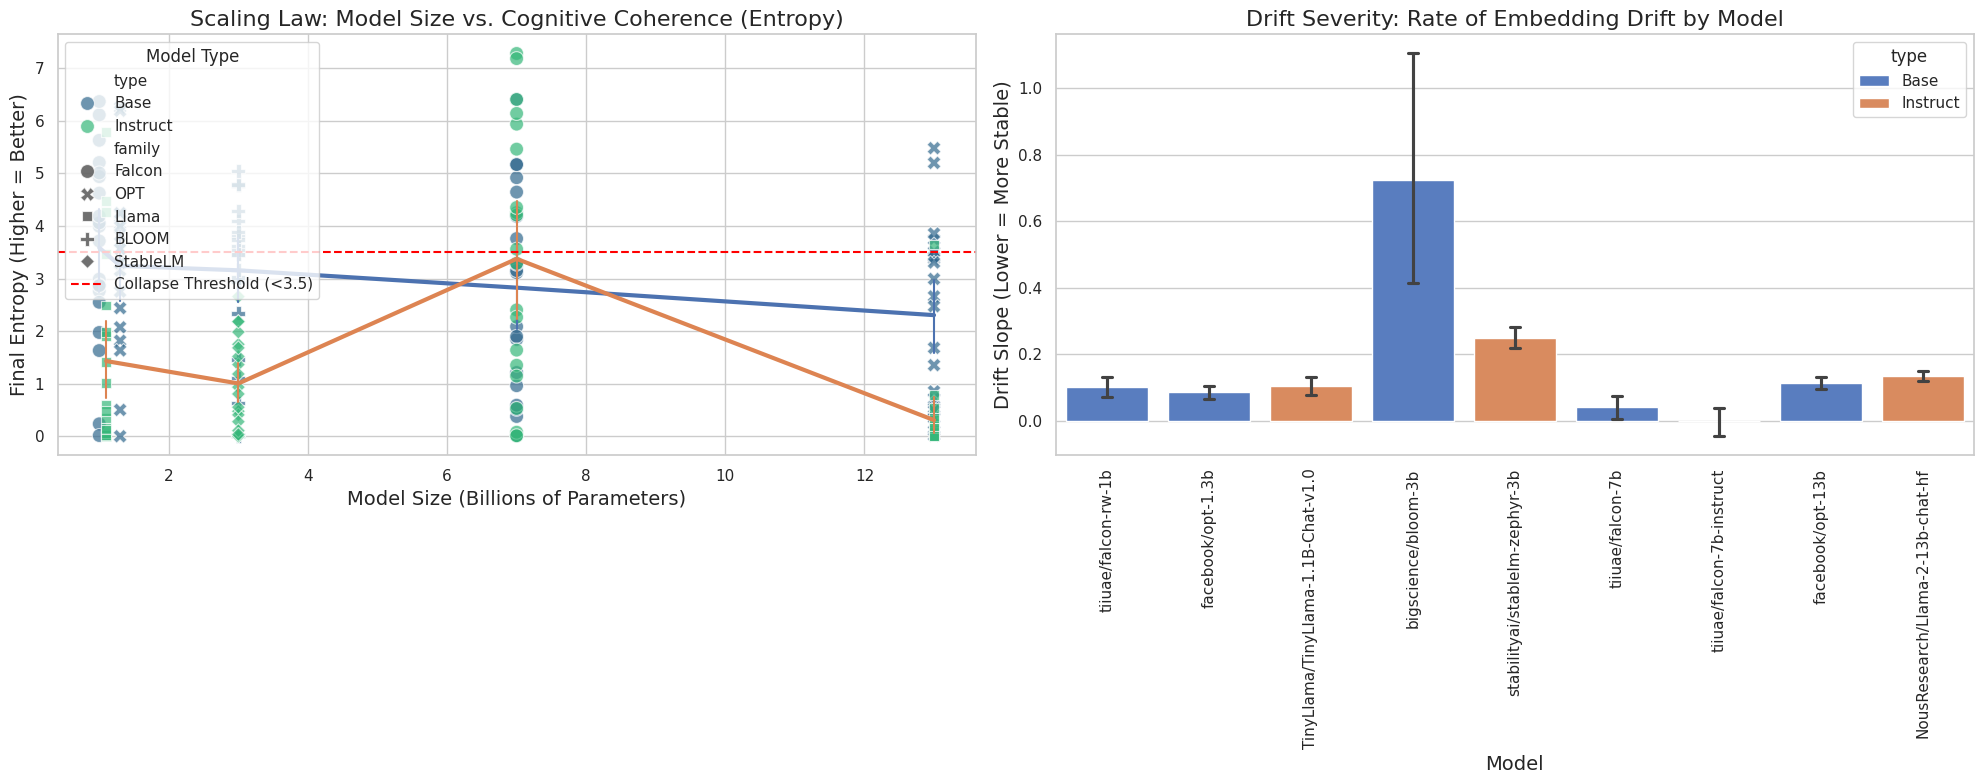

In [ ]:
# MAIN PIPELINE
if __name__ == "__main__":
    prompts = get_data()
    all_results = []

    # Run all models
    for m in MODELS:
        res = run_model_test(m, prompts)
        all_results.extend(res)

    df = pd.DataFrame(all_results)
    df.to_csv("rq4_final_report.csv", index=False)
    print("\n Experiment Complete. Data saved to rq4_final_report.csv")

    if not df.empty:
        # A. Summary Table
        summary = df.groupby(['model', 'type', 'size']).agg({
            'drift_slope': ['mean', 'std'],
            'final_entropy': ['mean', 'std']
        }).reset_index()
        summary.columns = ['Model', 'Type', 'Size (B)', 'Drift Mean', 'Drift Std', 'Entropy Mean', 'Entropy Std']
        summary = summary.sort_values('Size (B)')

        print("\n=== FINAL SCALING SUMMARY TABLE ===")
        print(summary.to_markdown(index=False, floatfmt=".3f"))

        # B. Figures
        sns.set_theme(style="whitegrid")
        fig, axes = plt.subplots(1, 2, figsize=(20, 8))

        # We plot the raw data points to show distribution + consistency
        sns.scatterplot(
            data=df, x='size', y='final_entropy',
            hue='type', style='family', s=100, alpha=0.7, ax=axes[0], palette='viridis'
        )
        # Add a trend line or mean points
        sns.lineplot(
            data=df, x='size', y='final_entropy', hue='type',
            err_style='bars', ci=95, ax=axes[0], legend=False, linewidth=3
        )
        axes[0].set_title("Scaling Law: Model Size vs. Cognitive Coherence (Entropy)", fontsize=16)
        axes[0].set_ylabel("Final Entropy (Higher = Better)", fontsize=14)
        axes[0].set_xlabel("Model Size (Billions of Parameters)", fontsize=14)
        axes[0].axhline(3.5, color='red', linestyle='--', label='Collapse Threshold (<3.5)')
        axes[0].legend(title="Model Type", loc='upper left')

        # Figure 2: Drift Slope by Model
        sns.barplot(
            data=df, x='model', y='drift_slope', hue='type',
            palette='muted', ax=axes[1], dodge=False, capsize=.1
        )
        axes[1].set_title("Drift Severity: Rate of Embedding Drift by Model", fontsize=16)
        axes[1].set_ylabel("Drift Slope (Lower = More Stable)", fontsize=14)
        axes[1].set_xlabel("Model", fontsize=14)
        axes[1].tick_params(axis='x', rotation=90)

        plt.tight_layout()
        plt.savefig("rq4_analysis_plots.png", dpi=300)
        print("\n Plots saved to rq4_analysis_plots.png")
    else:
        print("No results collected.")

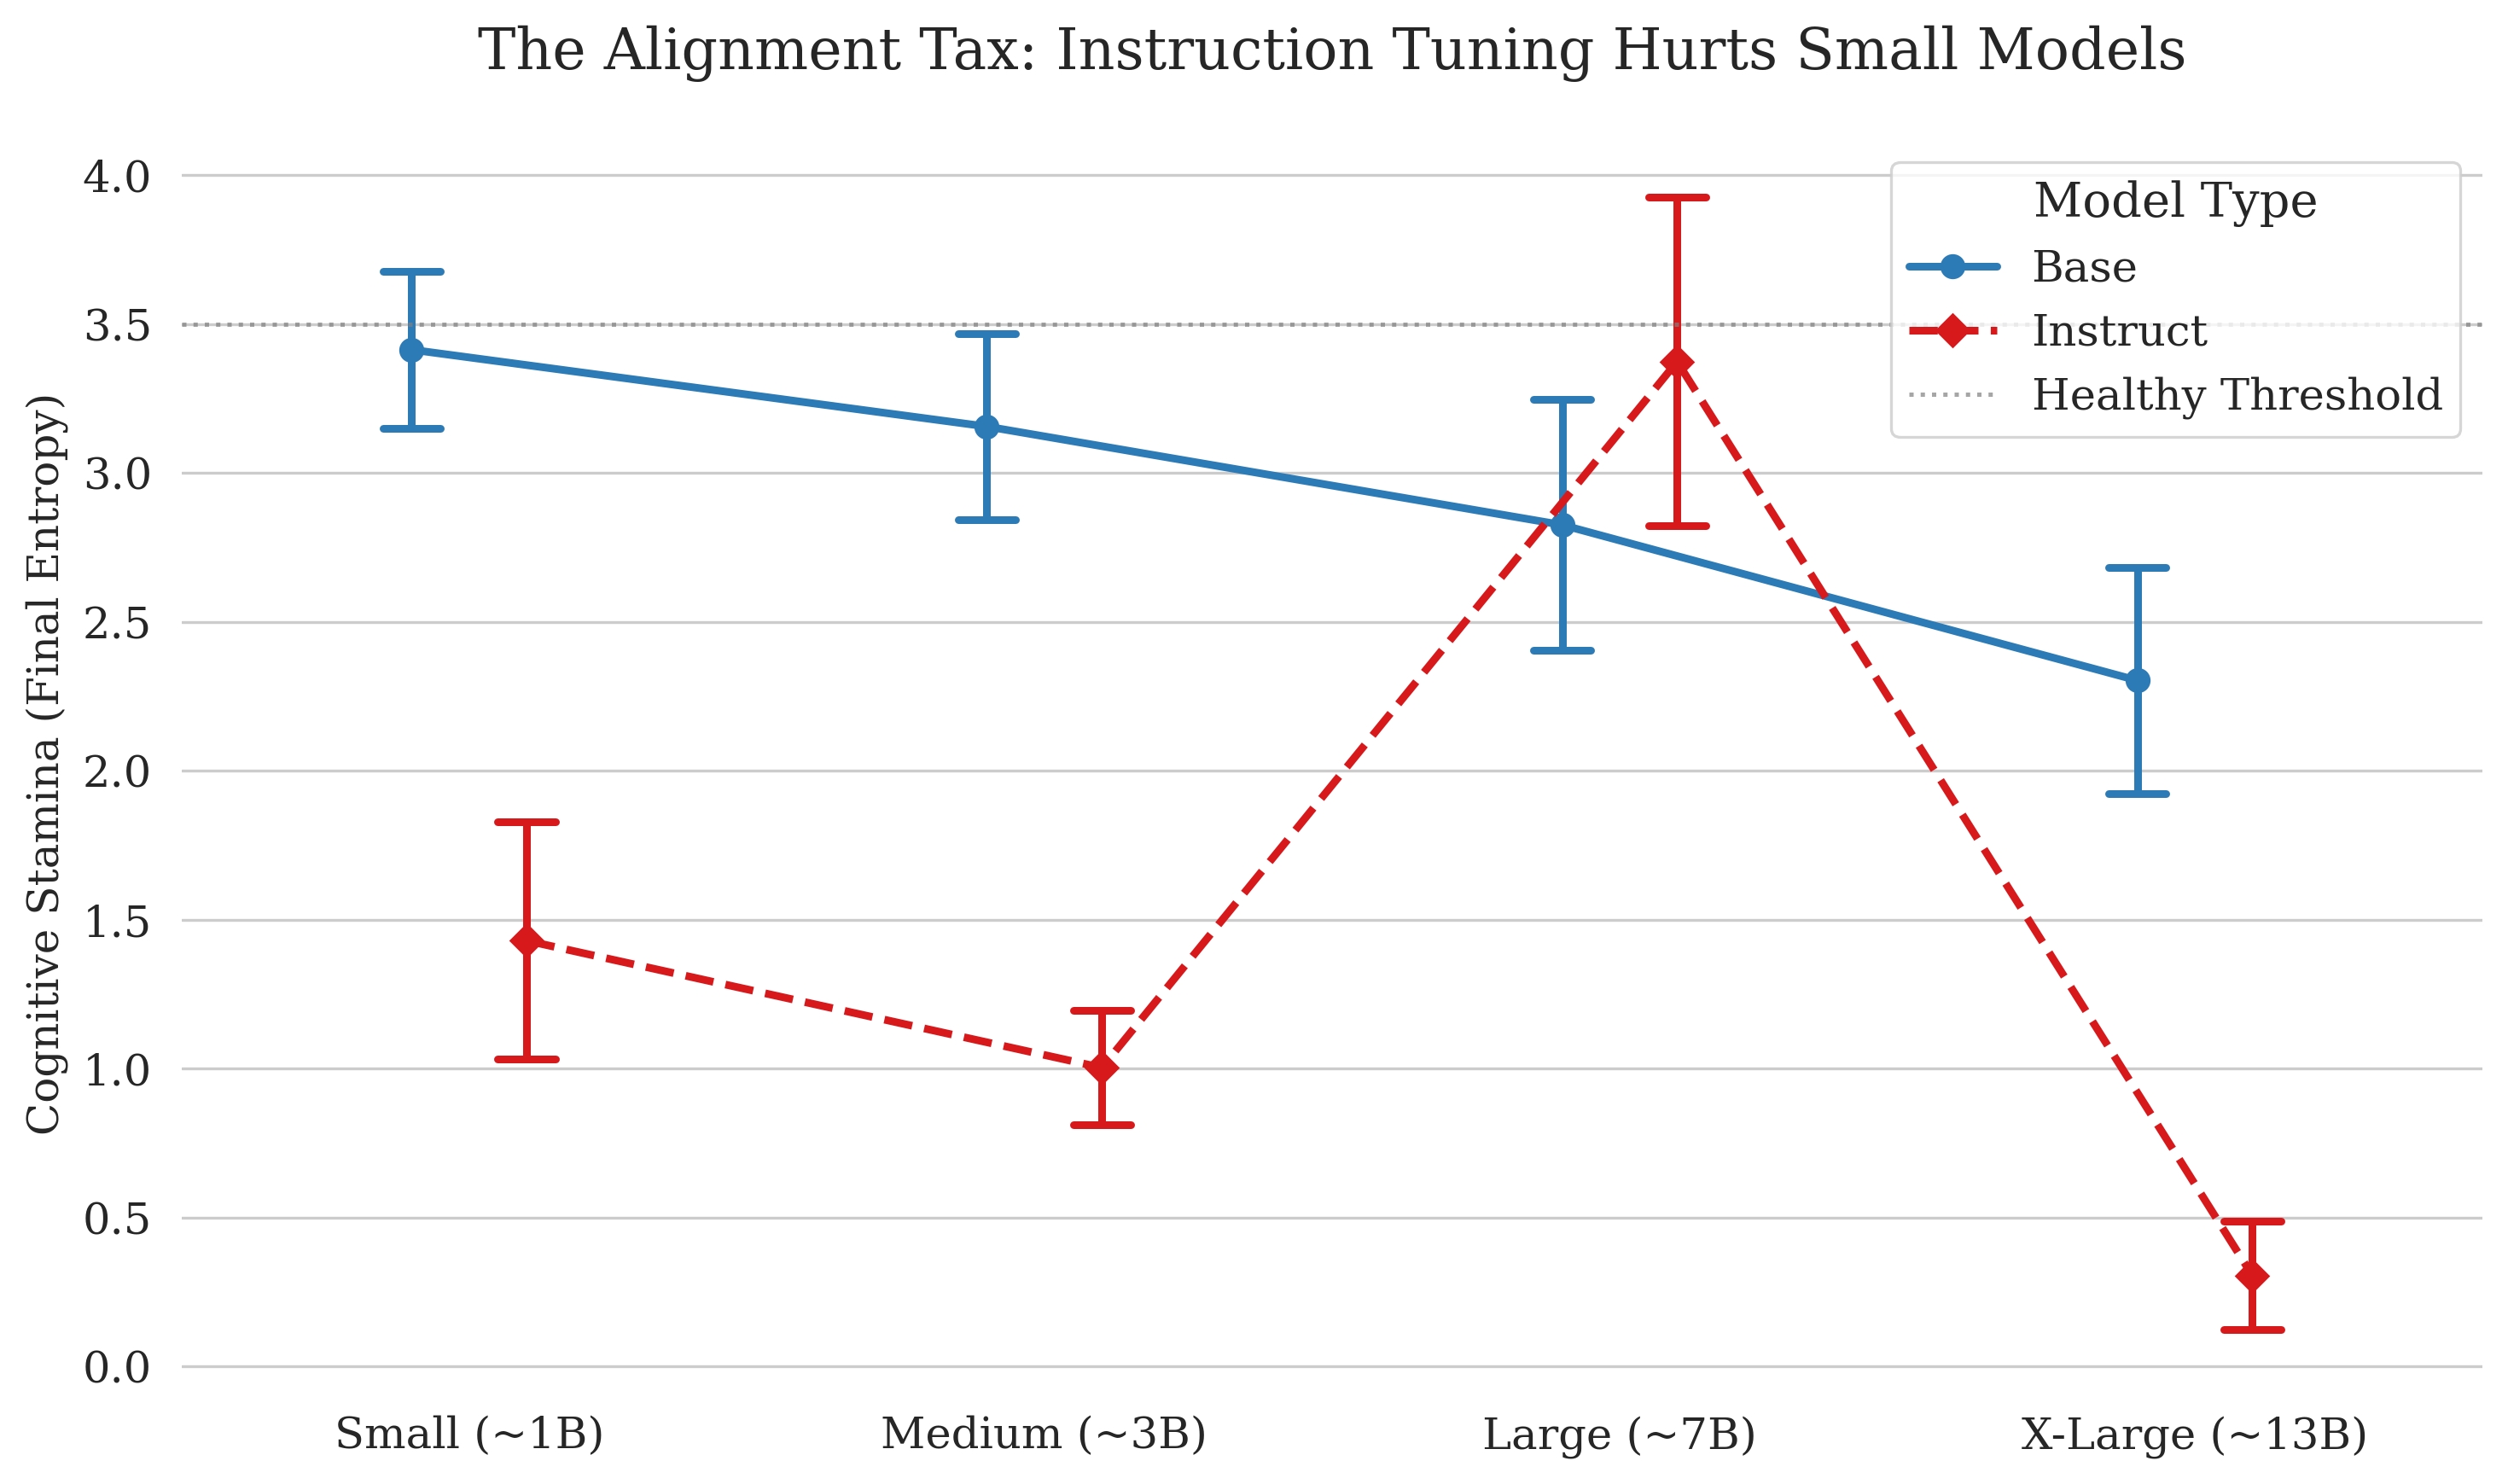

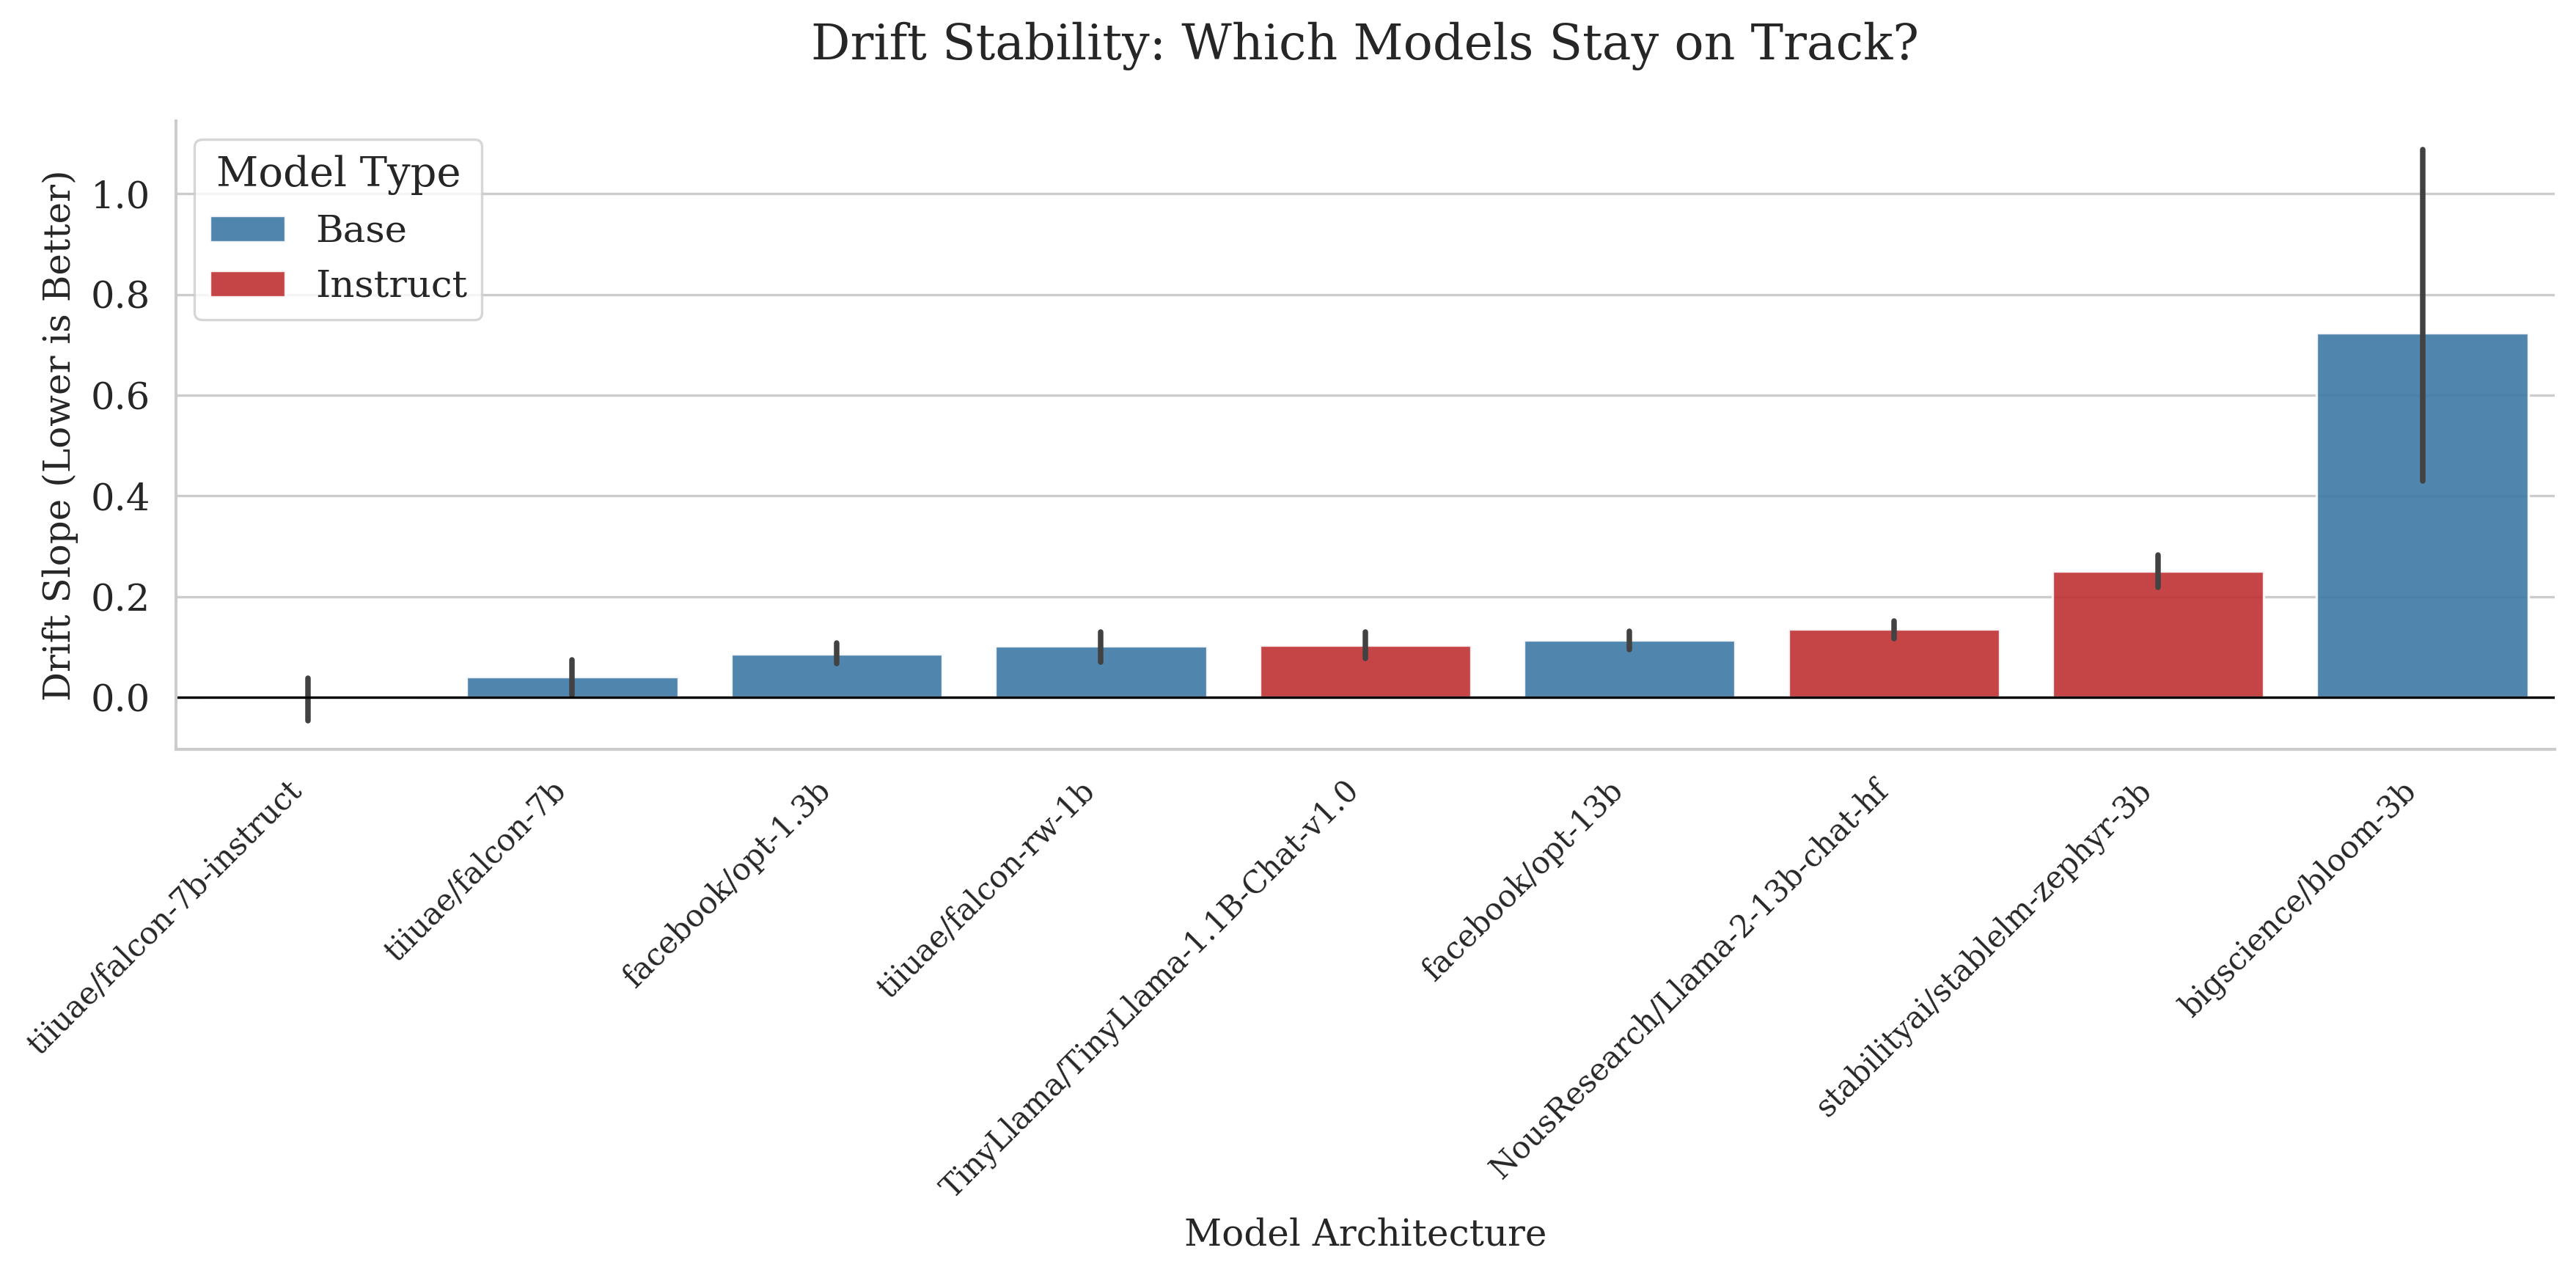

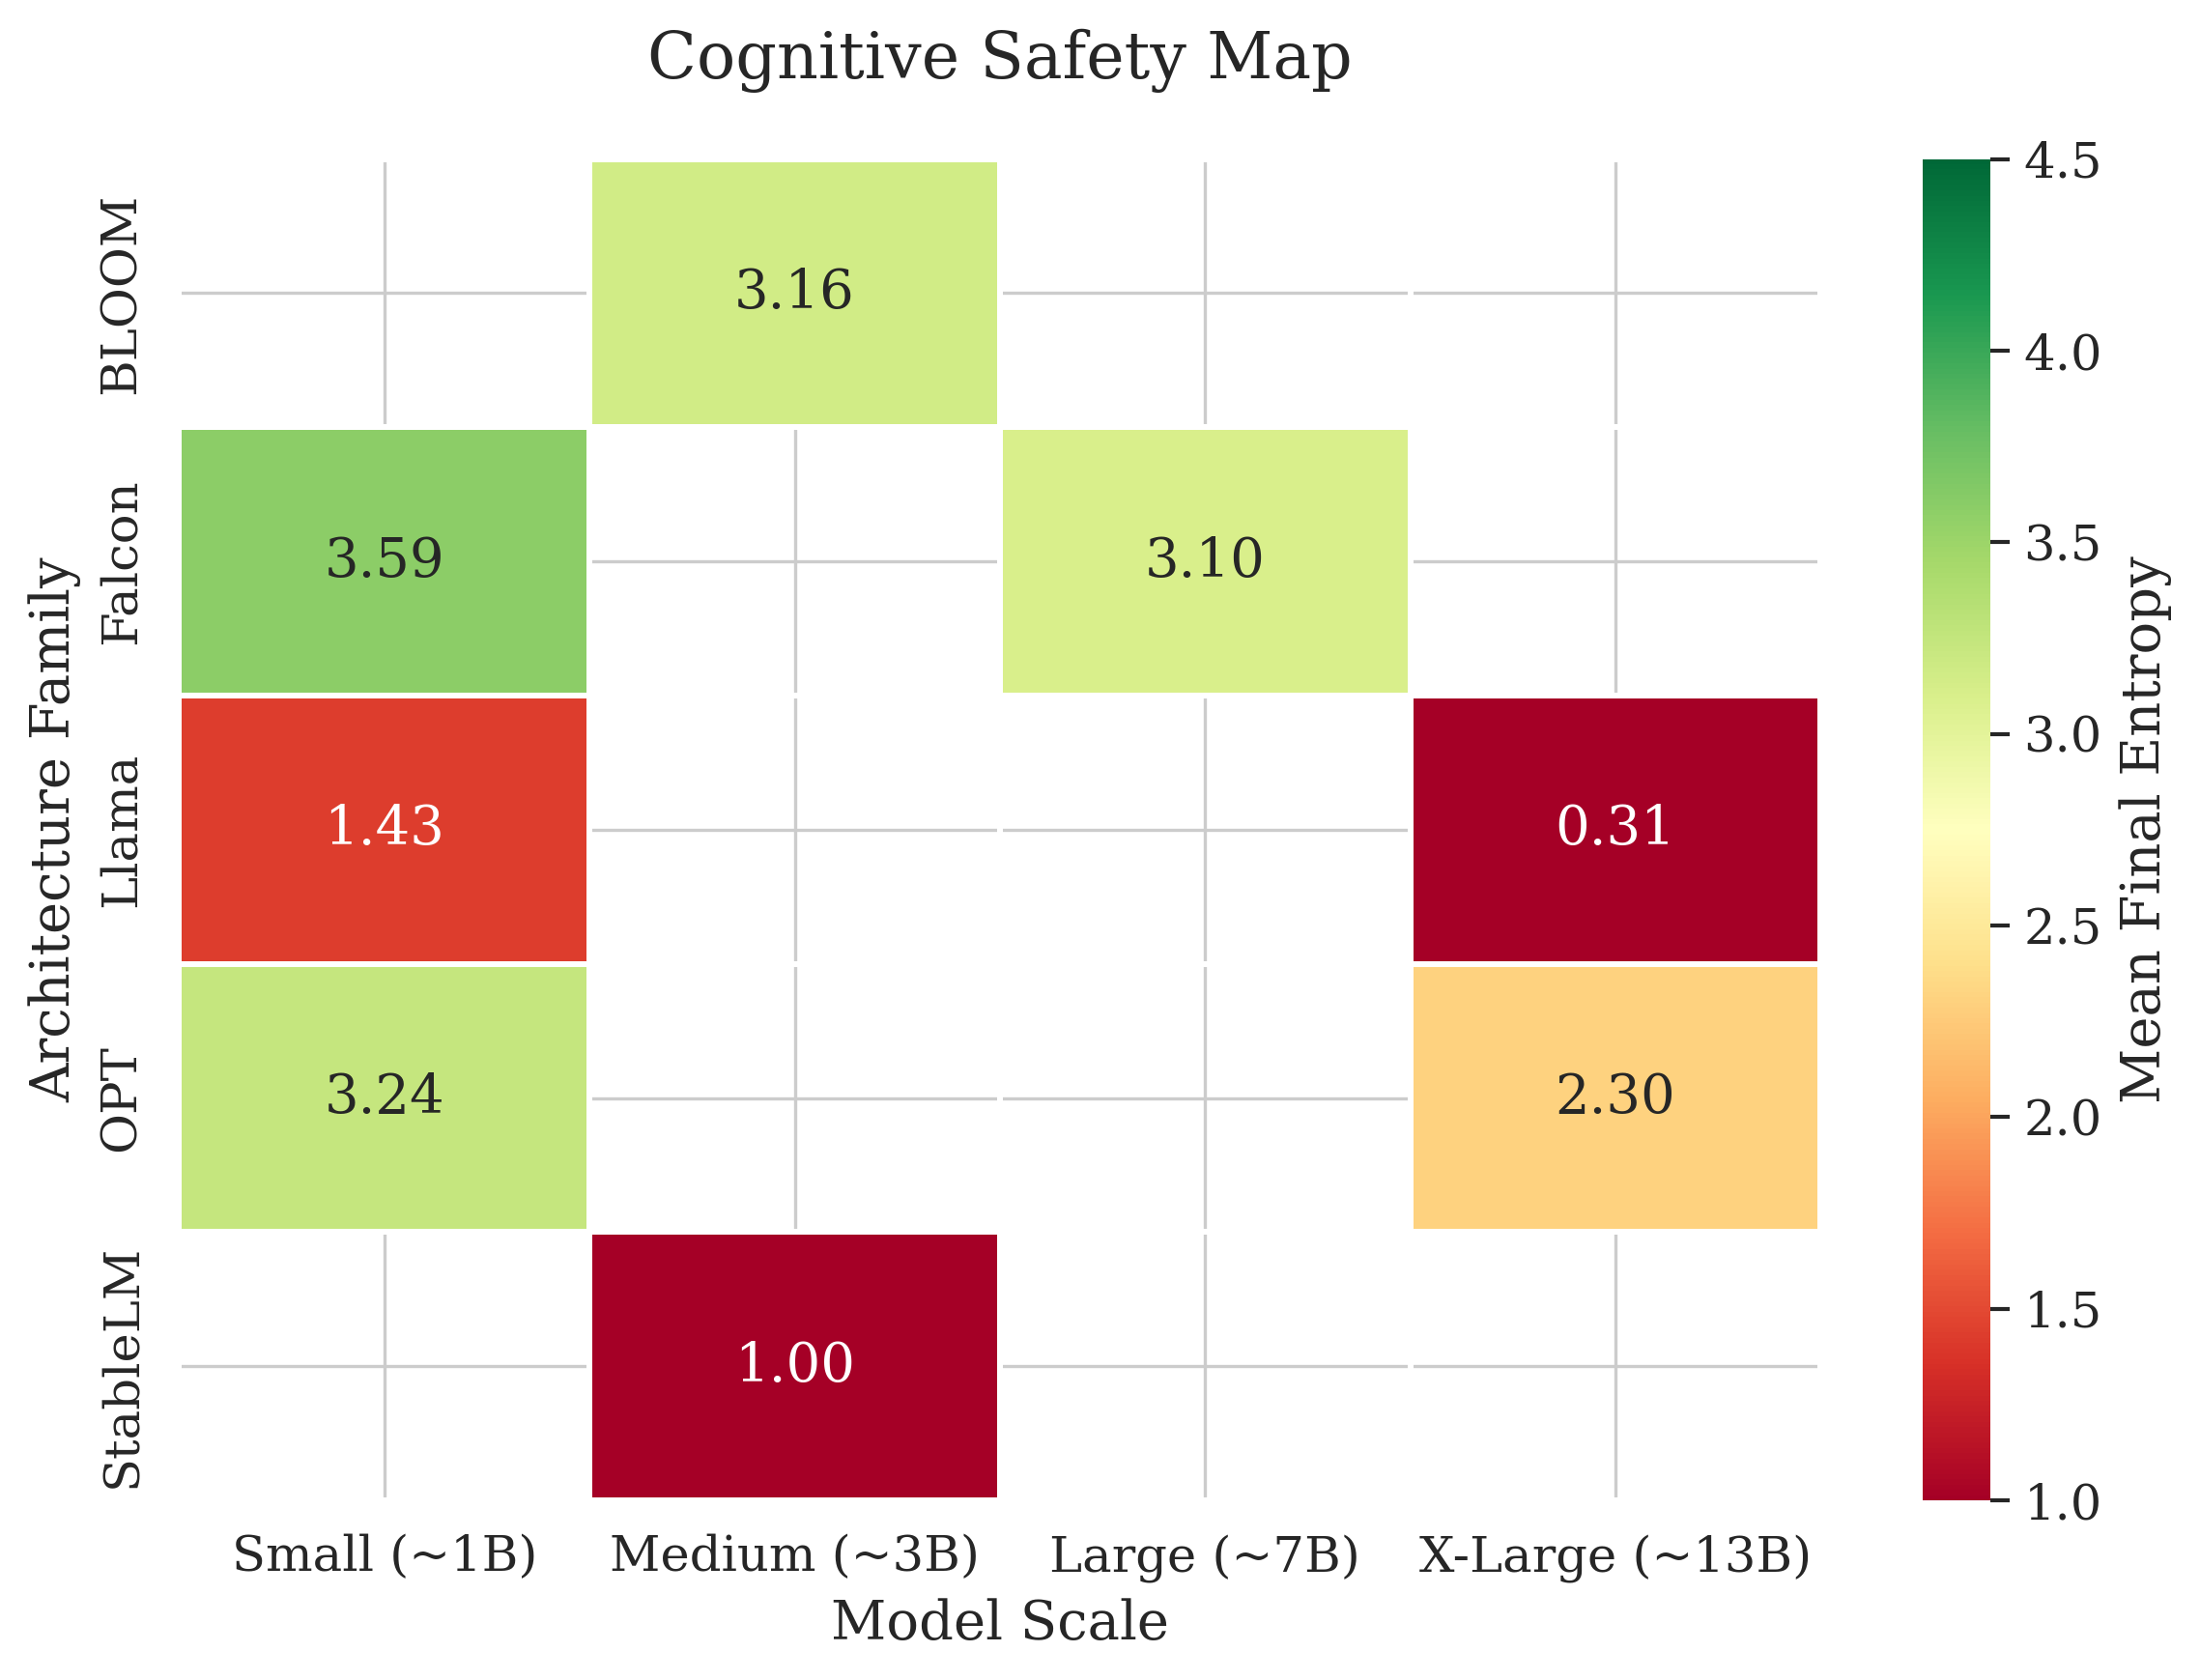

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

sns.set_theme(style="whitegrid", context="paper", font_scale=1.4)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['figure.dpi'] = 300
df = pd.read_csv('/content/rq4_final_report.csv')

# Categorize for cleaner plotting
def categorize_size(s):
    if s < 2: return "Small (~1B)"
    if s < 5: return "Medium (~3B)"
    if s < 10: return "Large (~7B)"
    return "X-Large (~13B)"

df['Size Category'] = df['size'].apply(categorize_size)
size_order = ["Small (~1B)", "Medium (~3B)", "Large (~7B)", "X-Large (~13B)"]

plt.figure(figsize=(10, 6))

palette = {"Base": "#2c7bb6", "Instruct": "#d7191c"}

ax = sns.pointplot(
    data=df,
    x="Size Category",
    y="final_entropy",
    hue="type",
    order=size_order,
    palette=palette,
    markers=["o", "D"],
    linestyles=["-", "--"],
    dodge=0.2,
    capsize=0.1,
    errorbar='se' # Standard Error
)


plt.title("The Alignment Tax: Instruction Tuning Hurts Small Models", fontsize=16, pad=20)
plt.ylabel("Cognitive Stamina (Final Entropy)", fontsize=12)
plt.xlabel("", fontsize=12)
plt.axhline(3.5, color='gray', linestyle=':', alpha=0.7, label='Healthy Threshold')

plt.legend(title="Model Type", loc='upper right', frameon=True)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.savefig("Fig1_Alignment_Tax_HighRes.png", bbox_inches='tight')
plt.show()

plt.figure(figsize=(12, 6))

rank = df.groupby('model')['drift_slope'].mean().sort_values().index

ax2 = sns.barplot(
    data=df,
    x="model",
    y="drift_slope",
    hue="type",
    order=rank, # Sorted by stability
    palette=palette,
    alpha=0.9
)

plt.title("Drift Stability: Which Models Stay on Track?", fontsize=16, pad=20)
plt.ylabel("Drift Slope (Lower is Better)", fontsize=12)
plt.xlabel("Model Architecture", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.axhline(0, color='black', linewidth=0.8)

plt.legend(title="Model Type")
sns.despine()

plt.tight_layout()
plt.savefig("Fig2_Drift_Stability_HighRes.png", bbox_inches='tight')
plt.show()

pivot_table = df.pivot_table(
    index="family",
    columns="Size Category",
    values="final_entropy",
    aggfunc="mean"
)[size_order]

plt.figure(figsize=(8, 6))
sns.heatmap(
    pivot_table,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    vmin=1.0,
    vmax=4.5,
    linewidths=1,
    linecolor='white',
    cbar_kws={'label': 'Mean Final Entropy'}
)

plt.title("Cognitive Safety Map", fontsize=16, pad=20)
plt.xlabel("Model Scale")
plt.ylabel("Architecture Family")

plt.tight_layout()
plt.savefig("Fig3_Safety_Map_HighRes.png", bbox_inches='tight')
plt.show()